# GRU による 3成分分離
## I_obs(t) = I_true(t) + e_sys(t) + e_noise(t)

| 成分 | 内容 |
|------|------|
| `I_true` | 真値（Malus則ベース線形増加） |
| `e_sys`  | 系統誤差 = α + β·t |
| `e_noise`| ランダムノイズ ~ N(0, σ²) |

### リーク防止の設計
- **TV正則化**: `e_sys` をスムーズに保つ
- **ゼロ平均制約**: `e_noise` が定数バイアスを吸収しない
- **直交性制約**: `e_sys` と `e_noise` が互いに情報を持ち寄らない
- **再構成整合性**: `true + sys + noise ≈ obs`


In [33]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU最適化フラグ（RTX 5060 Ti + Ryzen 7 8700Fを想定）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = min(6, max(2, (os.cpu_count() or 4) - 2))
PIN_MEMORY = device.type == 'cuda'
PERSISTENT_WORKERS = NUM_WORKERS > 0
AMP_ENABLED = device.type == 'cuda'

if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    if hasattr(torch, 'set_float32_matmul_precision'):
        torch.set_float32_matmul_precision('high')

print(f"Device: {device}")
print(f"NUM_WORKERS={NUM_WORKERS}, PIN_MEMORY={PIN_MEMORY}, AMP_ENABLED={AMP_ENABLED}")



Device: cuda


## 1. ハイパーパラメータ

In [34]:
# ─── データ生成パラメータ ───────────────────────────
N_RUNS       = 6       # 総Run数（訓練用）
N_TEST_RUNS  = 2       # テスト用Run数
T_PER_RUN    = 1500      # 1Run当たりのステップ数
SEQ_LEN      = 50       # GRU入力シーケンス長
NOISE_STD    = 1.0      # ランダムノイズ標準偏差

# 系統誤差パラメータ（Run毎にランダムサンプリング → 丸暗記防止）
OFFSET_RANGE = (-5.0,  5.0)    # 定数オフセット α
DRIFT_RANGE  = (-0.01, 0.01)   # 線形ドリフト係数 β

# ─── 学習パラメータ ──────────────────────────────────
BATCH_SIZE   = 256
EPOCHS       = 100
LR           = 1e-3
HIDDEN_SIZE  = 64
NUM_LAYERS   = 2

# ─── 損失重みパラメータ ──────────────────────────────
LAM_TV       = 0.01   # TV正則化（sys のスムーズ制約）
LAM_ZERO     = 0.10   # ゼロ平均制約（noise のバイアス除去）
LAM_ORTHO    = 0.05   # 直交性制約（sys ↔ noise）
LAM_RECON    = 1.00   # 再構成整合性

print("パラメータ設定完了")


パラメータ設定完了


## 2. データ生成

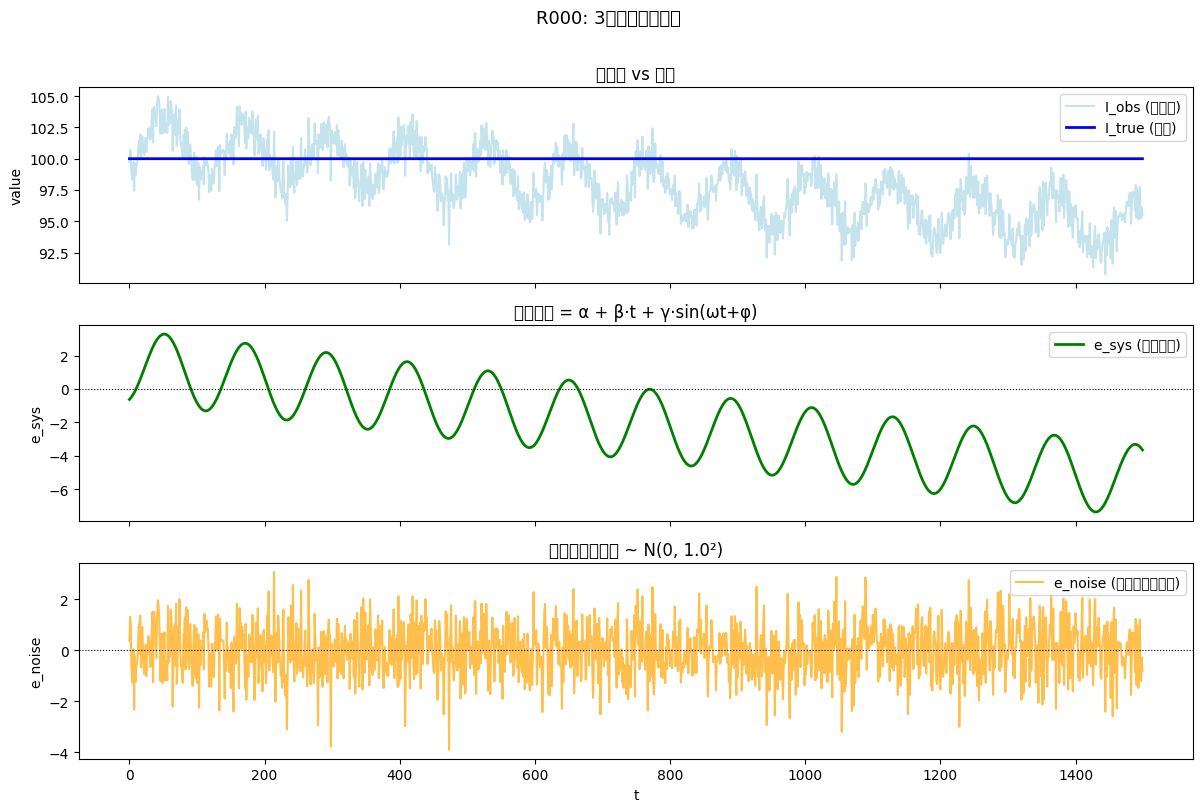

e_sys  振幅: 2.51
e_noise std: 0.99


In [35]:
def generate_run(run_id, T=T_PER_RUN, noise_std=NOISE_STD):
    """
    1Run分のデータを生成。
    Returns: t, I_true, e_sys, e_noise, I_obs  (各 shape: (T,))
    """
    rng = np.random.default_rng(run_id)
    t = np.arange(T, dtype=np.float32)

    # 真値: 線形増加（Run毎に傾き・切片を変化）
    I_true = np.full(T, 100.0, dtype=np.float32)

    # 系統誤差: e_sys = α + β·t
    alpha = rng.uniform(*OFFSET_RANGE)
    beta  = rng.uniform(*DRIFT_RANGE)
    e_sys = (alpha + beta * t).astype(np.float32)

    # ランダムノイズ
    e_noise = rng.normal(0, noise_std, size=T).astype(np.float32)

    # 観測値
    I_obs = I_true + e_sys + e_noise
    return t, I_true, e_sys, e_noise, I_obs


# ─── データ確認プロット ──────────────────────────────
t, I_true, e_sys, e_noise, I_obs = generate_run(0)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, I_obs,   color='lightblue', alpha=0.7, label='I_obs (観測値)')
axes[0].plot(t, I_true,  color='blue',  lw=2, label='I_true (真値)')
axes[0].set_ylabel('value'); axes[0].legend(); axes[0].set_title('観測値 vs 真値')

axes[1].plot(t, e_sys, color='green', lw=2, label='e_sys (系統誤差)')
axes[1].axhline(0, color='k', lw=0.8, ls=':')
axes[1].set_ylabel('e_sys'); axes[1].legend(); axes[1].set_title('系統誤差 = α + β·t')

axes[2].plot(t, e_noise, color='orange', alpha=0.7, label='e_noise (ランダムノイズ)')
axes[2].axhline(0, color='k', lw=0.8, ls=':')
axes[2].set_ylabel('e_noise'); axes[2].legend()
axes[2].set_title(f'ランダムノイズ ~ N(0, {NOISE_STD}²)')
axes[2].set_xlabel('t')

plt.suptitle('R000: 3成分の真値確認', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"e_sys  振幅: {e_sys.std():.2f}")
print(f"e_noise std: {e_noise.std():.2f}")


In [36]:
def build_sequences(runs_data, seq_len=SEQ_LEN):
    """
    スライディングウィンドウでシーケンスを構築。
    X       : (N, seq_len, 1)  入力: I_obs
    Y_true  : (N,)             ターゲット: I_true（末端ステップ）
    Y_sys   : (N, seq_len)     ターゲット: e_sys（全ステップ）
    Y_noise : (N, seq_len)     ターゲット: e_noise（全ステップ）
    """
    X_list, Yt_list, Ys_list, Yn_list = [], [], [], []
    for (_, I_true, e_sys, e_noise, I_obs) in runs_data:
        T = len(I_obs)
        for s in range(T - seq_len):
            e = s + seq_len
            X_list.append(I_obs[s:e].reshape(-1, 1))
            Yt_list.append(I_true[e - 1])
            Ys_list.append(e_sys[s:e])
            Yn_list.append(e_noise[s:e])
    return (np.array(X_list,  dtype=np.float32),
            np.array(Yt_list, dtype=np.float32),
            np.array(Ys_list, dtype=np.float32),
            np.array(Yn_list, dtype=np.float32))


# ─── 全Runデータ生成 ─────────────────────────────────
all_runs   = [generate_run(i) for i in range(N_RUNS + N_TEST_RUNS)]
train_runs = all_runs[:N_RUNS]
test_runs  = all_runs[N_RUNS:]

X_tr, Yt_tr, Ys_tr, Yn_tr = build_sequences(train_runs)
X_te, Yt_te, Ys_te, Yn_te = build_sequences(test_runs)

print(f"Train X: {X_tr.shape}  |  Test X: {X_te.shape}")
print(f"Train Y_sys: {Ys_tr.shape}")


Train X: (8700, 50, 1)  |  Test X: (2900, 50, 1)
Train Y_sys: (8700, 50)


In [37]:
# I_obs の統計量で正規化（ターゲットも同スケールで変換）
scaler  = StandardScaler()
N_tr, L, C = X_tr.shape
N_te       = X_te.shape[0]

X_tr_s = scaler.fit_transform(X_tr.reshape(-1, 1)).reshape(N_tr, L, C).astype(np.float32)
X_te_s = scaler.transform(X_te.reshape(-1, 1)).reshape(N_te, L, C).astype(np.float32)

mu    = scaler.mean_[0]
sigma = scaler.scale_[0]

Yt_tr_s = ((Yt_tr - mu) / sigma).astype(np.float32)
Ys_tr_s = (Ys_tr / sigma).astype(np.float32)
Yn_tr_s = (Yn_tr / sigma).astype(np.float32)
Yt_te_s = ((Yt_te - mu) / sigma).astype(np.float32)
Ys_te_s = (Ys_te / sigma).astype(np.float32)
Yn_te_s = (Yn_te / sigma).astype(np.float32)

print(f"正規化完了  mu={mu:.3f}  sigma={sigma:.3f}")


正規化完了  mu=100.593  sigma=7.305


In [38]:
class DecompDataset(Dataset):
    def __init__(self, X, Y_true, Y_sys, Y_noise):
        self.X       = torch.tensor(X,       dtype=torch.float32)
        self.Y_true  = torch.tensor(Y_true,  dtype=torch.float32)
        self.Y_sys   = torch.tensor(Y_sys,   dtype=torch.float32)
        self.Y_noise = torch.tensor(Y_noise, dtype=torch.float32)

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y_true[idx], self.Y_sys[idx], self.Y_noise[idx]


def make_loader(dataset, batch_size, shuffle, drop_last=False):
    kwargs = dict(
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
    )
    if NUM_WORKERS > 0:
        kwargs['prefetch_factor'] = 4
    return DataLoader(dataset, **kwargs)


train_ds     = DecompDataset(X_tr_s, Yt_tr_s, Ys_tr_s, Yn_tr_s)
test_ds      = DecompDataset(X_te_s, Yt_te_s, Ys_te_s, Yn_te_s)
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")



Train batches: 33  |  Test batches: 12


## 3. モデル定義（3ヘッドGRU）

In [39]:
class GRUDecomposer(nn.Module):
    """
    3ヘッドGRU: 共有エンコーダ + 独立ヘッド

    入力:  I_obs シーケンス  (B, L, 1)
    出力:
        true_pred  : 真値推定        (B, L)
        sys_pred   : 系統誤差推定    (B, L)
        noise_pred : ランダムノイズ推定 (B, L)
    """
    def __init__(self, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size  = 1,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )

        def _head():
            return nn.Sequential(
                nn.Linear(hidden_size, 32),
                nn.Tanh(),
                nn.Linear(32, 1),
            )

        # 独立ヘッド（重みを共有しないことでリークを抑制）
        self.head_true  = _head()
        self.head_sys   = _head()
        self.head_noise = _head()

    def forward(self, x):
        h, _ = self.gru(x)                             # (B, L, H)
        true_pred  = self.head_true(h).squeeze(-1)     # (B, L)
        sys_pred   = self.head_sys(h).squeeze(-1)      # (B, L)
        noise_pred = self.head_noise(h).squeeze(-1)    # (B, L)
        return true_pred, sys_pred, noise_pred


model = GRUDecomposer().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"モデルパラメータ数: {total_params:,}")
print(model)


モデルパラメータ数: 44,163
GRUDecomposer(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.1)
  (head_true): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
  (head_sys): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
  (head_noise): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 4. 損失関数（リーク防止の核心）

In [40]:
def tv_loss(x):
    """Total Variation: sys のスムーズ制約（高周波成分の吸収防止）"""
    return torch.mean(torch.abs(x[:, 1:] - x[:, :-1]))

def zero_mean_loss(x):
    """ゼロ平均制約: noise が定数バイアスを吸収しない"""
    return torch.mean(x.mean(dim=1) ** 2)

def orthogonality_loss(a, b):
    """直交性制約: sys と noise の相関を最小化"""
    a_c = a - a.mean(dim=1, keepdim=True)
    b_c = b - b.mean(dim=1, keepdim=True)
    cos = torch.sum(a_c * b_c, dim=1) / (
        a_c.norm(dim=1) * b_c.norm(dim=1) + 1e-8
    )
    return torch.mean(cos ** 2)

def reconstruction_loss(tp, sp, np_, x_obs):
    """再構成整合性: true + sys + noise ≈ obs"""
    return nn.functional.mse_loss(tp + sp + np_, x_obs.squeeze(-1))

def compute_loss(tp, sp, np_, Y_true, Y_sys, Y_noise, X):
    """
    総合損失 = 教師あり損失 + 正則化項
    """
    # 教師あり損失（末端ステップで真値、全ステップで sys/noise）
    L_true  = nn.functional.mse_loss(tp[:, -1], Y_true)
    L_sys   = nn.functional.mse_loss(sp, Y_sys)
    L_noise = nn.functional.mse_loss(np_, Y_noise)

    # 正則化項
    L_tv    = tv_loss(sp)
    L_zero  = zero_mean_loss(np_)
    L_ortho = orthogonality_loss(sp, np_)
    L_recon = reconstruction_loss(tp, sp, np_, X)

    total = (L_true + L_sys + L_noise
             + LAM_TV    * L_tv
             + LAM_ZERO  * L_zero
             + LAM_ORTHO * L_ortho
             + LAM_RECON * L_recon)

    detail = dict(
        true=L_true.item(), sys=L_sys.item(), noise=L_noise.item(),
        tv=L_tv.item(), zero=L_zero.item(), ortho=L_ortho.item(), recon=L_recon.item()
    )
    return total, detail

print("損失関数定義完了")
print(f"  LAM_TV={LAM_TV}  LAM_ZERO={LAM_ZERO}  LAM_ORTHO={LAM_ORTHO}  LAM_RECON={LAM_RECON}")


損失関数定義完了
  LAM_TV=0.01  LAM_ZERO=0.1  LAM_ORTHO=0.05  LAM_RECON=1.0


## 1-b. ハイパーパラメータ探索（グリッドサーチ）

### 探索対象パラメータ一覧

| カテゴリ | パラメータ | 候補値 |
|---|---|---|
| データ生成 | `N_RUNS` | 4, 6, 8 |
| データ生成 | `T_PER_RUN` | 1000, 1500 |
| データ生成 | `SEQ_LEN` | 30, 50, 100 |
| モデル | `HIDDEN_SIZE` | 32, 64, 128 |
| モデル | `NUM_LAYERS` | 1, 2 |
| モデル | `dropout` | 0.0, 0.1, 0.2 |
| 学習 | `BATCH_SIZE` | 128, 256 |
| 学習 | `LR` | 1e-3, 5e-4 |
| 損失重み | `LAM_TV` | 0.01, 0.05 |
| 損失重み | `LAM_ZERO` | 0.05, 0.10 |
| 損失重み | `LAM_ORTHO` | 0.01, 0.05, 0.10 |
| 損失重み | `LAM_RECON` | 0.5, 1.0, 2.0 |

> **⚠️ 注意**: 全組み合わせ数は非常に多くなります。  
> `SEARCH_EPOCHS` を小さく（例: 30〜50）に設定するか、  
> グリッドの候補値を絞ってから実行することを推奨します。  
> 途中中断 → 再実行時は **完了済み条件をスキップ** して再開します。


In [ ]:
# ════════════════════════════════════════════════════════════════════
# ハイパーパラメータ探索（グリッドサーチ） + 結果CSV逐次記録
# ════════════════════════════════════════════════════════════════════
import itertools, time, os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

# ── ① 探索グリッド定義（候補値をここで編集）────────────────────
SEARCH_GRID = {
    # データ生成
    # ※ NOISE_STD は固定値（Cell 3 の設定値を使用）
    "N_RUNS"      : [4, 6, 8],
    "T_PER_RUN"   : [1000, 1500],
    "SEQ_LEN"     : [30, 50, 100],
    # モデル構造
    "HIDDEN_SIZE" : [32, 64, 128],
    "NUM_LAYERS"  : [1, 2],
    "dropout"     : [0.0, 0.1, 0.2],
    # 学習
    "BATCH_SIZE"  : [128, 256],
    "LR"          : [1e-3, 5e-4],
    # 損失重み
    "LAM_TV"      : [0.01, 0.05],
    "LAM_ZERO"    : [0.05, 0.10],
    "LAM_ORTHO"   : [0.01, 0.05, 0.10],
    "LAM_RECON"   : [0.5, 1.0, 2.0],
}

SEARCH_EPOCHS = 50   # 探索時エポック数（本番より少なめ推奨）
INFER_BATCH_SIZE = 2048
DATA_CACHE = {}

CSV_DIR    = "csv_output"
CSV_SEARCH = os.path.join(CSV_DIR, "hyperparam_search.csv")
os.makedirs(CSV_DIR, exist_ok=True)

# ── ② 全組み合わせ生成 ──────────────────────────────────────────
keys   = list(SEARCH_GRID.keys())
combos = list(itertools.product(*[SEARCH_GRID[k] for k in keys]))
print(f"総組み合わせ数: {len(combos):,}")

# ── ③ 既完了条件の読み込み（中断再開対応）──────────────────────
if os.path.exists(CSV_SEARCH):
    df_done  = pd.read_csv(CSV_SEARCH)
    done_set = set(
        tuple(row[k] for k in keys)
        for _, row in df_done.iterrows()
    )
    print(f"既完了: {len(done_set):,} 条件 → 残り {len(combos)-len(done_set):,} 条件")
else:
    done_set = set()
    print("新規探索を開始します")


# ── ④ 損失関数（hp引数版）──────────────────────────────────────
def _compute_loss_hp(tp, sp, np_, Y_true, Y_sys, Y_noise, X, hp):
    L_true  = nn.functional.mse_loss(tp[:, -1], Y_true)
    L_sys   = nn.functional.mse_loss(sp, Y_sys)
    L_noise = nn.functional.mse_loss(np_, Y_noise)
    L_tv    = tv_loss(sp)
    L_zero  = zero_mean_loss(np_)
    L_ortho = orthogonality_loss(sp, np_)
    L_recon = reconstruction_loss(tp, sp, np_, X)
    total = (L_true + L_sys + L_noise
             + hp["LAM_TV"]    * L_tv
             + hp["LAM_ZERO"]  * L_zero
             + hp["LAM_ORTHO"] * L_ortho
             + hp["LAM_RECON"] * L_recon)
    return total


# ── ⑤ 1条件の学習・評価関数 ─────────────────────────────────────
def _make_fast_loader(dataset, batch_size, shuffle, drop_last=False):
    kwargs = dict(
        batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=PERSISTENT_WORKERS
    )
    if NUM_WORKERS > 0:
        kwargs["prefetch_factor"] = 4
    return DataLoader(dataset, **kwargs)


def run_one_condition(hp: dict) -> dict:
    """
    データ生成 → 正規化 → DataLoader → 学習 → RMSE評価 を1セットで実行。
    データ生成パラメータ(N_RUNS, T_PER_RUN, SEQ_LEN)が変わっても正しく対応する。NOISE_STDはCell3の固定値。
    """
    # ※ NOISE_STD は固定値（Cell 3 の設定値を使用）
    n_runs     = hp["N_RUNS"]
    t_per_run  = hp["T_PER_RUN"]
    seq_len    = hp["SEQ_LEN"]
    noise_std  = NOISE_STD        # Cell 3 の固定値を使用
    hidden     = hp["HIDDEN_SIZE"]
    num_layers = hp["NUM_LAYERS"]
    dropout    = hp["dropout"]
    batch_size = hp["BATCH_SIZE"]
    lr         = hp["LR"]

    cache_key = (n_runs, t_per_run, seq_len, float(noise_std))
    if cache_key not in DATA_CACHE:
        # ─ データ生成 ─
        _all_runs   = [generate_run(i, T=t_per_run, noise_std=noise_std)
                       for i in range(n_runs + N_TEST_RUNS)]
        _train_runs = _all_runs[:n_runs]
        _test_runs  = _all_runs[n_runs:]

        X_tr, Yt_tr, Ys_tr, Yn_tr = build_sequences(_train_runs, seq_len=seq_len)
        X_te, Yt_te, Ys_te, Yn_te = build_sequences(_test_runs,  seq_len=seq_len)

        # ─ 正規化 ─
        _scaler = StandardScaler()
        N_tr_, L_, C_ = X_tr.shape
        N_te_         = X_te.shape[0]
        X_tr_s = _scaler.fit_transform(X_tr.reshape(-1,1)).reshape(N_tr_, L_, C_).astype('float32')
        X_te_s = _scaler.transform(    X_te.reshape(-1,1)).reshape(N_te_, L_, C_).astype('float32')
        _mu, _sigma = float(_scaler.mean_[0]), float(_scaler.scale_[0])

        Yt_tr_s = ((Yt_tr - _mu) / _sigma).astype('float32')
        Ys_tr_s = (Ys_tr / _sigma).astype('float32')
        Yn_tr_s = (Yn_tr / _sigma).astype('float32')
        Yt_te_s = ((Yt_te - _mu) / _sigma).astype('float32')
        Ys_te_s = (Ys_te / _sigma).astype('float32')
        Yn_te_s = (Yn_te / _sigma).astype('float32')

        tr_ds = DecompDataset(X_tr_s, Yt_tr_s, Ys_tr_s, Yn_tr_s)
        te_ds = DecompDataset(X_te_s, Yt_te_s, Ys_te_s, Yn_te_s)

        test_windows = []
        for _, _, _, _, I_obs in _test_runs:
            I_obs_s = ((I_obs - _mu) / _sigma).astype('float32')
            n_windows = len(I_obs_s) - seq_len
            if n_windows <= 0:
                test_windows.append(None)
                continue
            wins = np.stack([I_obs_s[s:s+seq_len] for s in range(n_windows)], axis=0).astype('float32')
            test_windows.append(torch.from_numpy(wins[..., None]))

        DATA_CACHE[cache_key] = dict(
            tr_ds=tr_ds, te_ds=te_ds, test_runs=_test_runs,
            mu=_mu, sigma=_sigma, test_windows=test_windows
        )

    cached = DATA_CACHE[cache_key]
    tr_ds, te_ds = cached["tr_ds"], cached["te_ds"]
    _test_runs = cached["test_runs"]
    _mu, _sigma = cached["mu"], cached["sigma"]
    test_windows = cached["test_windows"]

    # ─ DataLoader ─
    tr_dl  = _make_fast_loader(tr_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    te_dl  = _make_fast_loader(te_ds, batch_size=batch_size, shuffle=False)

    # ─ モデル ─
    mdl = GRUDecomposer(hidden_size=hidden, num_layers=num_layers,
                        dropout=dropout).to(device)
    opt = optim.Adam(mdl.parameters(), lr=lr)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=8, factor=0.5)
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

    best_val, best_state = float('inf'), None

    for _ in range(SEARCH_EPOCHS):
        # Train
        mdl.train()
        for X_b, Yt_b, Ys_b, Yn_b in tr_dl:
            X_b  = X_b.to(device, non_blocking=PIN_MEMORY);  Yt_b = Yt_b.to(device, non_blocking=PIN_MEMORY)
            Ys_b = Ys_b.to(device, non_blocking=PIN_MEMORY); Yn_b = Yn_b.to(device, non_blocking=PIN_MEMORY)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                tp, sp, np_ = mdl(X_b)
                loss = _compute_loss_hp(tp, sp, np_, Yt_b, Ys_b, Yn_b, X_b, hp)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
        # Validate
        mdl.eval()
        va_total = 0.0
        with torch.no_grad():
            for X_b, Yt_b, Ys_b, Yn_b in te_dl:
                X_b  = X_b.to(device, non_blocking=PIN_MEMORY);  Yt_b = Yt_b.to(device, non_blocking=PIN_MEMORY)
                Ys_b = Ys_b.to(device, non_blocking=PIN_MEMORY); Yn_b = Yn_b.to(device, non_blocking=PIN_MEMORY)
                with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                    tp, sp, np_ = mdl(X_b)
                    val_loss = _compute_loss_hp(tp, sp, np_, Yt_b, Ys_b, Yn_b, X_b, hp)
                va_total += val_loss.item()
        va_loss = va_total / max(len(te_dl), 1)
        sch.step(va_loss)
        if va_loss < best_val:
            best_val   = va_loss
            best_state = {k: v.cpu().clone() for k, v in mdl.state_dict().items()}

    # ─ RMSE評価（テストRun） ─
    mdl.load_state_dict(best_state)
    mdl.eval()
    rmse_true_list, rmse_sys_list, rmse_noise_list = [], [], []

    for run_data, x_all in zip(_test_runs, test_windows):
        _, I_true, e_sys, e_noise, I_obs = run_data
        T = len(I_obs)
        true_arr  = np.full(T, np.nan, 'float32')
        sys_arr   = np.full(T, np.nan, 'float32')
        noise_arr = np.full(T, np.nan, 'float32')

        if x_all is not None:
            n_windows = x_all.shape[0]
            with torch.no_grad():
                for st in range(0, n_windows, INFER_BATCH_SIZE):
                    ed = min(st + INFER_BATCH_SIZE, n_windows)
                    xb = x_all[st:ed].to(device, non_blocking=PIN_MEMORY)
                    with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                        tp2, sp2, np2 = mdl(xb)
                    true_arr[st+seq_len:ed+seq_len]  = tp2[:, -1].detach().cpu().numpy()
                    sys_arr[st+seq_len:ed+seq_len]   = sp2[:, -1].detach().cpu().numpy()
                    noise_arr[st+seq_len:ed+seq_len] = np2[:, -1].detach().cpu().numpy()

        rmse_true_list.append( np.sqrt(np.nanmean((true_arr  *_sigma+_mu - I_true )**2)))
        rmse_sys_list.append(  np.sqrt(np.nanmean((sys_arr   *_sigma     - e_sys  )**2)))
        rmse_noise_list.append(np.sqrt(np.nanmean((noise_arr *_sigma     - e_noise)**2)))

    return dict(
        best_val_loss   = round(best_val, 6),
        rmse_true_mean  = round(float(np.mean(rmse_true_list)),  4),
        rmse_sys_mean   = round(float(np.mean(rmse_sys_list)),   4),
        rmse_noise_mean = round(float(np.mean(rmse_noise_list)), 4),
    )


# ── ⑥ グリッドサーチ本体 ─────────────────────────────────────────
header = (f"{'No':>5} | "
          + " | ".join(f"{k:<11}" for k in keys)
          + " | best_val   | RMSE_true | RMSE_sys  | RMSE_noise| time(s)")
print(header)
print("-" * len(header))

# ── 推定時間の初期表示 ──
_elapsed_log = []   # 完了した条件の所要時間を蓄積
_remaining   = len(combos) - len(done_set)
print(f"\n⏱  残り条件数: {_remaining:,} / {len(combos):,}")
if len(done_set) > 0 and os.path.exists(CSV_SEARCH):
    _df_done = pd.read_csv(CSV_SEARCH)
    if "time_sec" in _df_done.columns:
        _avg_sec = _df_done["time_sec"].mean()
        _eta_sec = _avg_sec * _remaining
        _h, _r   = divmod(int(_eta_sec), 3600)
        _m, _s   = divmod(_r, 60)
        print(f"⏱  既完了の平均時間: {_avg_sec:.1f}s/条件")
        print(f"⏱  推定残り時間   : {_h}h {_m}m {_s}s  ({_eta_sec/60:.1f} 分)")
else:
    print("⏱  推定残り時間: 最初の1条件完了後に表示されます")
print()



for idx, combo in enumerate(combos):
    hp         = dict(zip(keys, combo))
    key_tuple  = tuple(combo)

    if key_tuple in done_set:
        print(f"{idx+1:>5} | {' | '.join(f'{v:<11}' for v in combo)} | [SKIP]")
        continue

    t0      = time.time()
    metrics = run_one_condition(hp)
    elapsed = time.time() - t0

    row    = {**hp, **metrics, "epochs": SEARCH_EPOCHS, "time_sec": round(elapsed, 1)}
    df_row = pd.DataFrame([row])
    write_header = not os.path.exists(CSV_SEARCH)
    df_row.to_csv(CSV_SEARCH, mode="a", header=write_header, index=False, encoding="utf-8-sig")
    done_set.add(key_tuple)
    _elapsed_log.append(elapsed)
    _avg_sec   = sum(_elapsed_log) / len(_elapsed_log)
    _remaining = len(combos) - (idx + 1)
    _eta_sec   = _avg_sec * _remaining
    _h, _r     = divmod(int(_eta_sec), 3600)
    _m, _s     = divmod(_r, 60)
    print(f"    ⏱  avg {_avg_sec:.1f}s/条件  残り {_remaining:,}条件  ETA: {_h}h {_m}m {_s}s")


    print(
        f"{idx+1:>5} | {' | '.join(f'{v:<11}' for v in combo)}"
        f" | {metrics['best_val_loss']:>9.5f}"
        f" | {metrics['rmse_true_mean']:>9.4f}"
        f" | {metrics['rmse_sys_mean']:>9.4f}"
        f" | {metrics['rmse_noise_mean']:>9.4f}"
        f" | {elapsed:>7.1f}s"
    )

print(f"\n✅ 探索完了  →  {CSV_SEARCH}")





## 1-c. 探索結果サマリー
グリッドサーチ完了後に実行してください。


In [ ]:
# ── 探索結果の読み込みと整形表示 ────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import os

CSV_DIR    = "csv_output"
CSV_SEARCH = os.path.join(CSV_DIR, "hyperparam_search.csv")

df_result = pd.read_csv(CSV_SEARCH)
keys = ["N_RUNS","T_PER_RUN","SEQ_LEN",
        "HIDDEN_SIZE","NUM_LAYERS","dropout",
        "BATCH_SIZE","LR",
        "LAM_TV","LAM_ZERO","LAM_ORTHO","LAM_RECON"]

df_sorted = df_result.sort_values("rmse_true_mean").reset_index(drop=True)

print("=" * 80)
print("ハイパーパラメータ探索 結果一覧  (rmse_true_mean 昇順)")
print("=" * 80)
display(df_sorted)

# ── TOP-10 ──────────────────────────────────────────────────────
print("\n【TOP-10 条件 (rmse_true_mean が小さい順)】")
display(df_sorted.head(10))

# ── 最良条件の詳細 ───────────────────────────────────────────────
best = df_sorted.iloc[0]
print("\n【最良条件】")
for k in keys + ["best_val_loss","rmse_true_mean","rmse_sys_mean","rmse_noise_mean"]:
    if k in best:
        print(f"  {k:<20}: {best[k]}")

# ── 各パラメータ別 平均RMSE_true ─────────────────────────────────
print("\n【各パラメータ別 平均 rmse_true_mean】")
for k in keys:
    if k not in df_result.columns:
        continue
    grp = df_result.groupby(k)["rmse_true_mean"].mean().reset_index()
    grp.columns = [k, "mean_rmse_true"]
    grp["mean_rmse_true"] = grp["mean_rmse_true"].round(4)
    print(f"\n  {k}:")
    print(grp.to_string(index=False))

# ── 棒グラフ（RMSE 3指標）────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (metric, color) in zip(axes, [
    ("rmse_true_mean",  "steelblue"),
    ("rmse_sys_mean",   "green"),
    ("rmse_noise_mean", "orange"),
]):
    ax.bar(range(len(df_sorted)), df_sorted[metric], color=color, alpha=0.75)
    ax.axhline(df_sorted[metric].min(), color="red", ls="--", lw=1.2, label="min")
    ax.set_title(metric); ax.set_xlabel("条件 (rmse_true昇順)")
    ax.set_ylabel("RMSE"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.4)

plt.suptitle("Grid Search: RMSE per condition", fontsize=13)
plt.tight_layout()
plot_path = os.path.join(CSV_DIR, "hyperparam_search_plot.png")
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"\n📊 グラフ保存: {plot_path}")

# ── サマリーCSV保存 ──────────────────────────────────────────────
summary_path = os.path.join(CSV_DIR, "hyperparam_summary.csv")
df_sorted.to_csv(summary_path, index=False, encoding="utf-8-sig")
print(f"✅ サマリーCSV保存: {summary_path}")


## 5. 学習

In [41]:
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

train_losses, val_losses = [], []
best_val   = float('inf')
best_state = None

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    tr_total = 0.0
    for X_b, Yt_b, Ys_b, Yn_b in train_loader:
        X_b  = X_b.to(device, non_blocking=PIN_MEMORY)
        Yt_b = Yt_b.to(device, non_blocking=PIN_MEMORY)
        Ys_b = Ys_b.to(device, non_blocking=PIN_MEMORY)
        Yn_b = Yn_b.to(device, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            tp, sp, np_ = model(X_b)
            loss, _ = compute_loss(tp, sp, np_, Yt_b, Ys_b, Yn_b, X_b)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        tr_total += loss.item()
    tr_loss = tr_total / len(train_loader)

    # ── Validate ──
    model.eval()
    va_total = 0.0
    with torch.no_grad():
        for X_b, Yt_b, Ys_b, Yn_b in test_loader:
            X_b  = X_b.to(device, non_blocking=PIN_MEMORY)
            Yt_b = Yt_b.to(device, non_blocking=PIN_MEMORY)
            Ys_b = Ys_b.to(device, non_blocking=PIN_MEMORY)
            Yn_b = Yn_b.to(device, non_blocking=PIN_MEMORY)
            with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                tp, sp, np_ = model(X_b)
                loss, _ = compute_loss(tp, sp, np_, Yt_b, Ys_b, Yn_b, X_b)
            va_total += loss.item()
    va_loss = va_total / len(test_loader)

    scheduler.step(va_loss)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    if va_loss < best_val:
        best_val   = va_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  |  Train: {tr_loss:.5f}  |  Val: {va_loss:.5f}  |  Best: {best_val:.5f}")

# ベストモデルを復元
model.load_state_dict(best_state)
print(f"\n学習完了  Best Val Loss: {best_val:.5f}")



Epoch  10/100  |  Train: 0.02715  |  Val: 0.02424  |  Best: 0.02424
Epoch  20/100  |  Train: 0.01675  |  Val: 0.01568  |  Best: 0.01562
Epoch  30/100  |  Train: 0.01558  |  Val: 0.01467  |  Best: 0.01461
Epoch  40/100  |  Train: 0.01526  |  Val: 0.01438  |  Best: 0.01434
Epoch  50/100  |  Train: 0.01490  |  Val: 0.01451  |  Best: 0.01421
Epoch  60/100  |  Train: 0.01464  |  Val: 0.01435  |  Best: 0.01420
Epoch  70/100  |  Train: 0.01430  |  Val: 0.01431  |  Best: 0.01417
Epoch  80/100  |  Train: 0.01423  |  Val: 0.01429  |  Best: 0.01408
Epoch  90/100  |  Train: 0.01406  |  Val: 0.01423  |  Best: 0.01408
Epoch 100/100  |  Train: 0.01393  |  Val: 0.01419  |  Best: 0.01408

学習完了  Best Val Loss: 0.01408


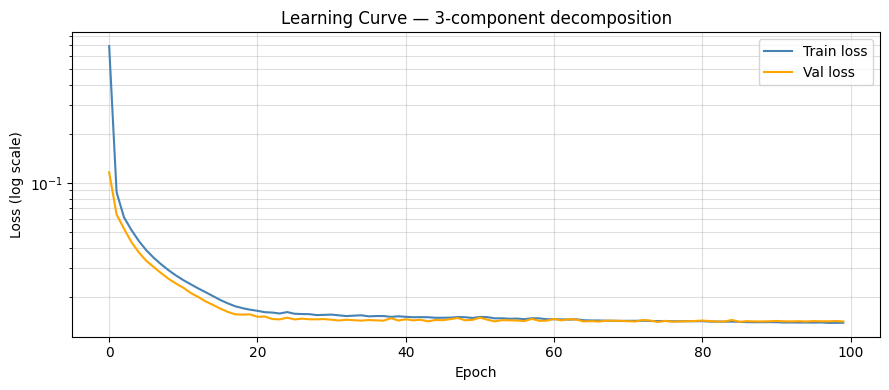

In [42]:
plt.figure(figsize=(9, 4))
plt.semilogy(train_losses, label='Train loss', color='steelblue')
plt.semilogy(val_losses,   label='Val loss',   color='orange')
plt.xlabel('Epoch'); plt.ylabel('Loss (log scale)')
plt.title('Learning Curve — 3-component decomposition')
plt.legend(); plt.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# ─── 学習曲線を CSV に保存 ───────────────────────────────
import pandas as pd, os

os.makedirs("csv_output", exist_ok=True)

df_curve = pd.DataFrame({
    "epoch"      : list(range(1, len(train_losses) + 1)),
    "train_loss" : train_losses,
    "val_loss"   : val_losses,
})

path_curve = "csv_output/learning_curve.csv"
df_curve.to_csv(path_curve, index=False, encoding="utf-8-sig")
print(f"✅ 学習曲線CSV保存: {path_curve}  ({len(df_curve)} epochs)")
print(df_curve.head())


## 6. 推論・評価

In [43]:
def predict_run(model, I_obs, seq_len=SEQ_LEN, infer_batch_size=2048):
    """
    スライディングウィンドウで1Run全体を推論（バッチ化版）。
    末端ステップを採用（各ウィンドウの最後の予測を使用）。
    """
    model.eval()
    T = len(I_obs)
    true_arr  = np.full(T, np.nan, dtype=np.float32)
    sys_arr   = np.full(T, np.nan, dtype=np.float32)
    noise_arr = np.full(T, np.nan, dtype=np.float32)

    n_windows = T - seq_len
    if n_windows <= 0:
        return true_arr, sys_arr, noise_arr

    windows = np.stack([I_obs[s:s+seq_len] for s in range(n_windows)], axis=0).astype(np.float32)
    x_all = torch.from_numpy(windows[..., None])

    with torch.no_grad():
        for st in range(0, n_windows, infer_batch_size):
            ed = min(st + infer_batch_size, n_windows)
            xb = x_all[st:ed].to(device, non_blocking=PIN_MEMORY)
            with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                tp, sp, np_ = model(xb)

            true_arr[st+seq_len:ed+seq_len]  = tp[:, -1].detach().cpu().numpy()
            sys_arr[st+seq_len:ed+seq_len]   = sp[:, -1].detach().cpu().numpy()
            noise_arr[st+seq_len:ed+seq_len] = np_[:, -1].detach().cpu().numpy()

    return true_arr, sys_arr, noise_arr

print("推論関数定義完了")



推論関数定義完了


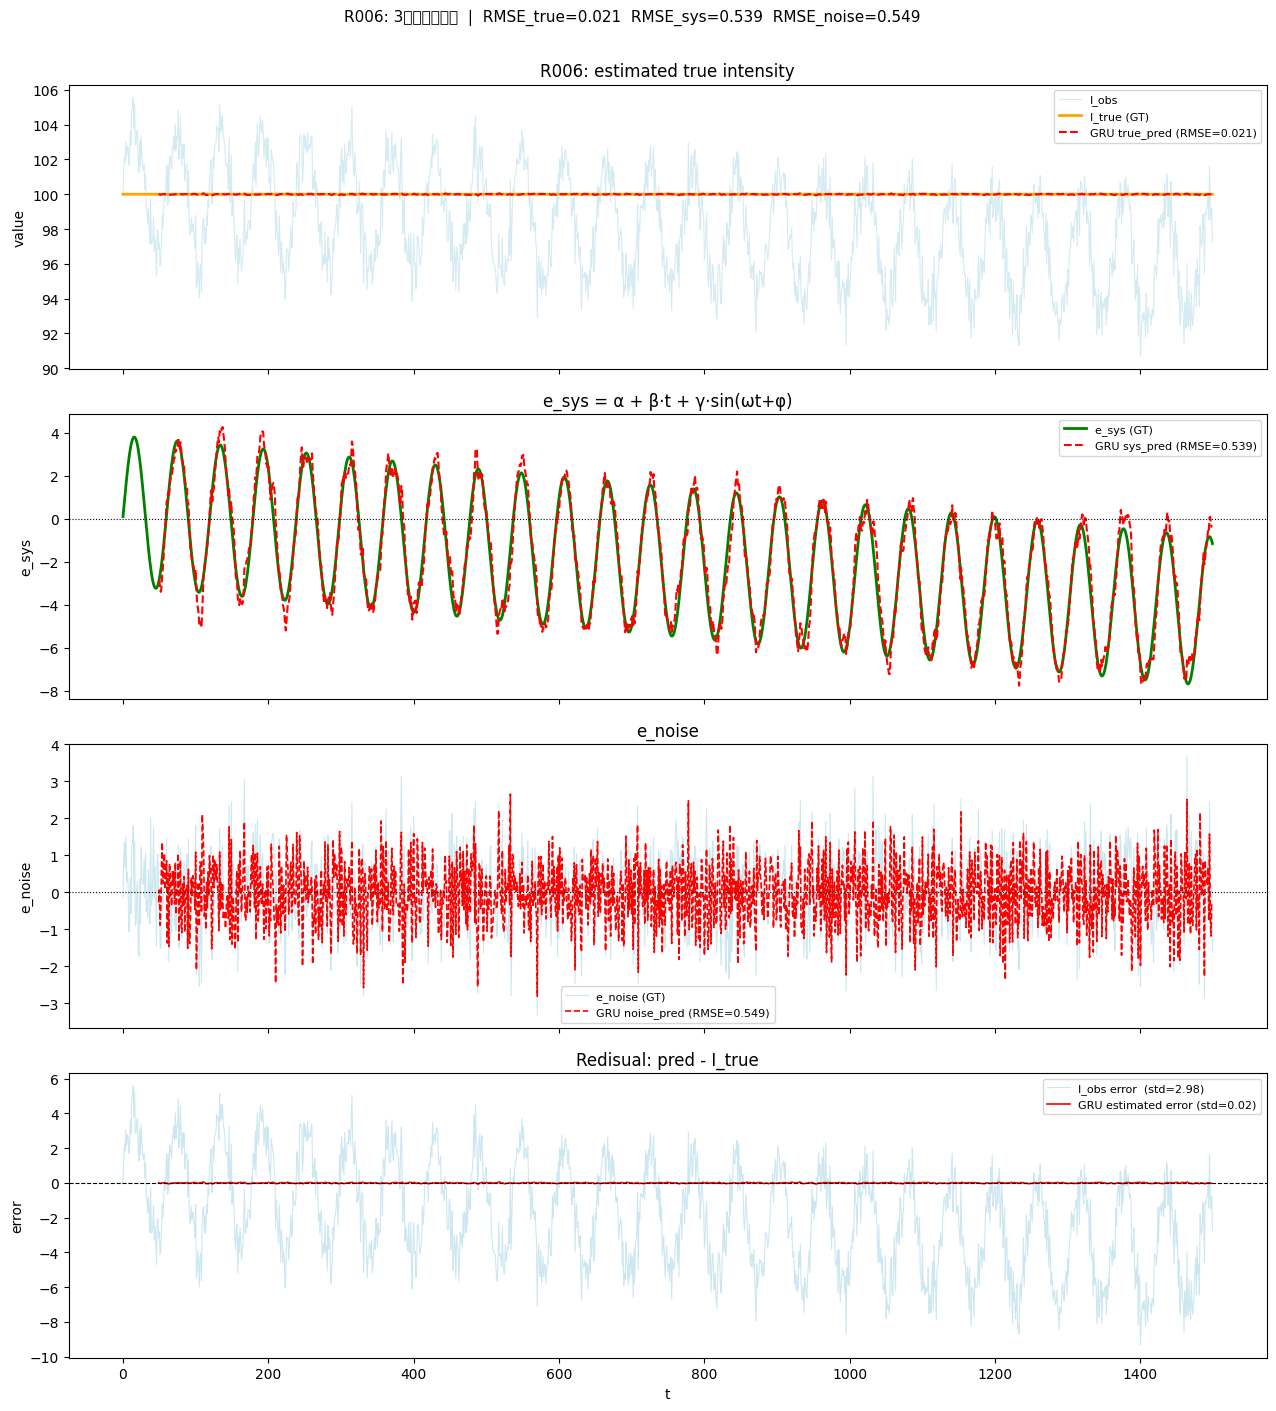

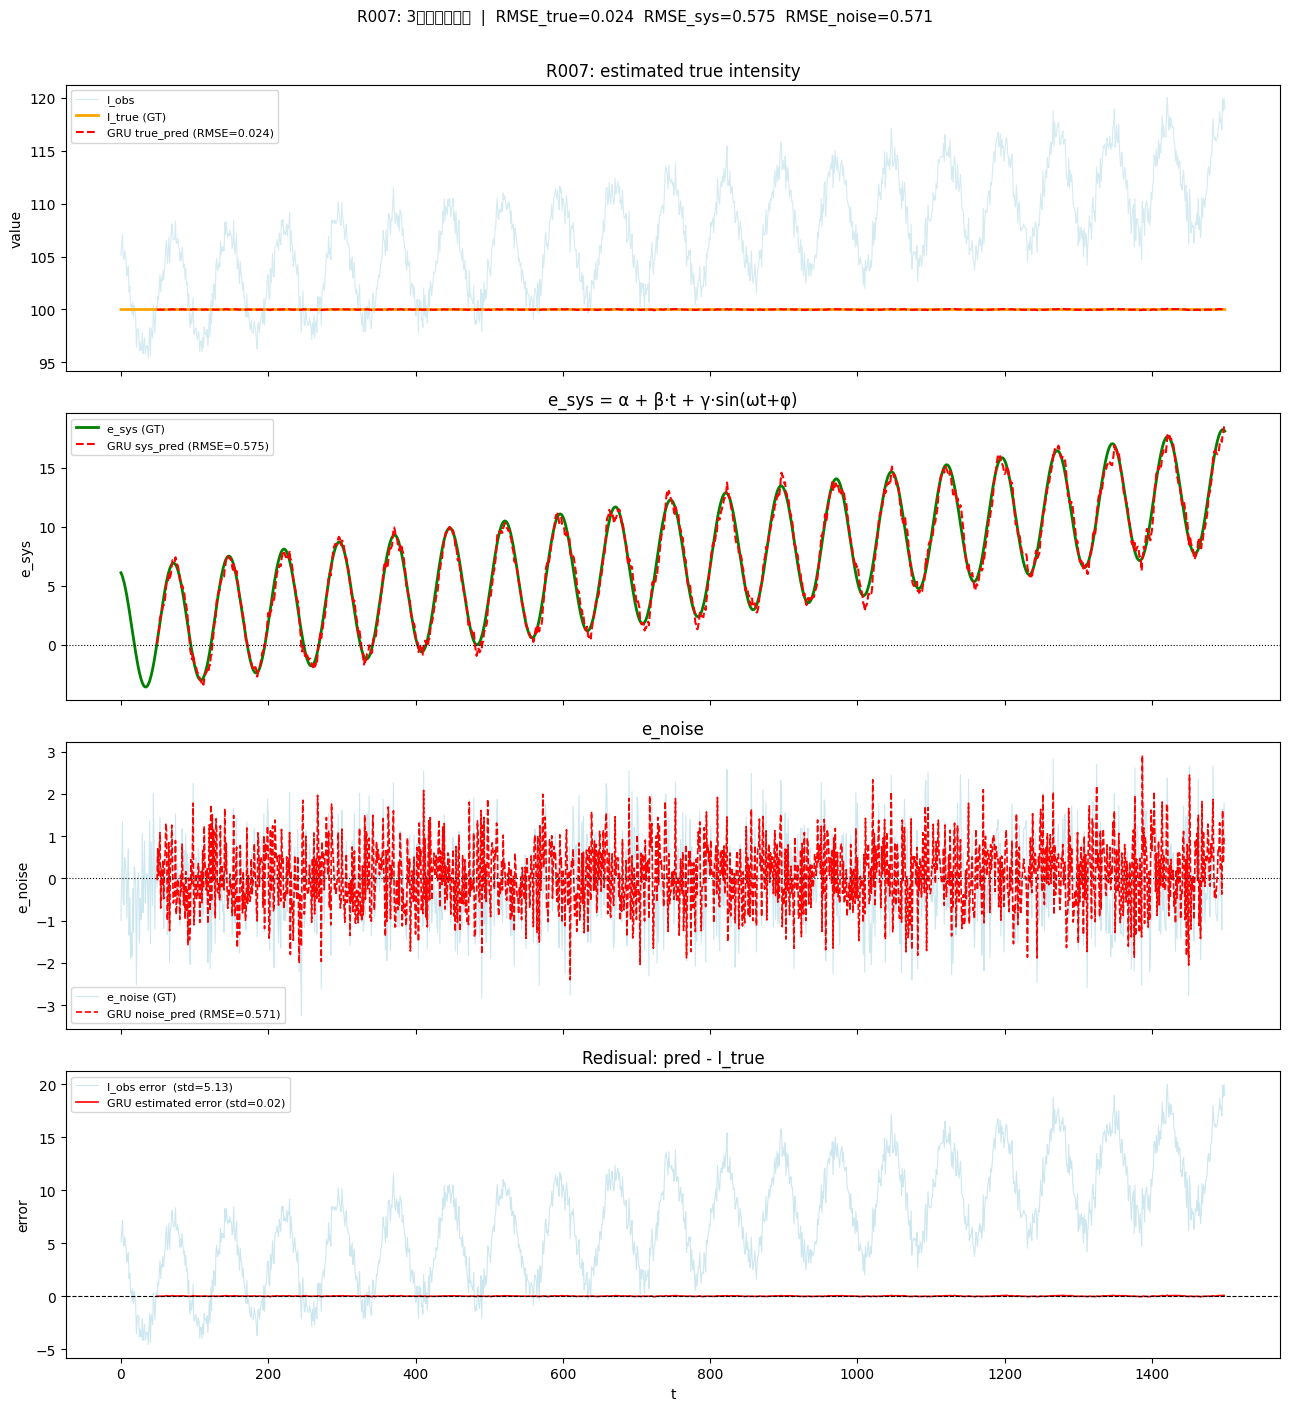

In [44]:
def plot_decomposition(run_data, run_id):
    t, I_true, e_sys, e_noise, I_obs = run_data

    # 正規化して推論
    I_obs_s             = ((I_obs - mu) / sigma).astype(np.float32)
    tp_s, sp_s, noise_s = predict_run(model, I_obs_s)

    # 逆変換
    true_pred  = tp_s    * sigma + mu
    sys_pred   = sp_s    * sigma
    noise_pred = noise_s * sigma
    mask = ~np.isnan(true_pred)

    # 評価指標
    rmse_true  = np.sqrt(np.nanmean((true_pred  - I_true )**2))
    rmse_sys   = np.sqrt(np.nanmean((sys_pred   - e_sys  )**2))
    rmse_noise = np.sqrt(np.nanmean((noise_pred - e_noise)**2))

    fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=True)

    # ── 真値推定 ──
    ax = axes[0]
    ax.plot(t, I_obs,  color='lightblue', alpha=0.5, lw=0.8, label='I_obs')
    ax.plot(t, I_true, color='orange',    lw=2.0,           label='I_true (GT)')
    ax.plot(t[mask], true_pred[mask], 'r--', lw=1.5,        label=f'GRU true_pred (RMSE={rmse_true:.3f})')
    ax.set_title(f'R{run_id:03d}: estimated true intensity')
    ax.set_ylabel('value'); ax.legend(fontsize=8)

    # ── 系統誤差 ──
    ax = axes[1]
    ax.plot(t, e_sys, color='green', lw=2.0,  label='e_sys (GT)')
    ax.plot(t[mask], sys_pred[mask], 'r--', lw=1.5, label=f'GRU sys_pred (RMSE={rmse_sys:.3f})')
    ax.axhline(0, color='k', lw=0.8, ls=':')
    ax.set_title('e_sys = α + β·t')
    ax.set_ylabel('e_sys'); ax.legend(fontsize=8)

    # ── ランダムノイズ ──
    ax = axes[2]
    ax.plot(t, e_noise, color='lightblue', alpha=0.6, lw=0.8, label='e_noise (GT)')
    ax.plot(t[mask], noise_pred[mask], 'r--', lw=1.2, label=f'GRU noise_pred (RMSE={rmse_noise:.3f})')
    ax.axhline(0, color='k', lw=0.8, ls=':')
    ax.set_title('e_noise')
    ax.set_ylabel('e_noise'); ax.legend(fontsize=8)

    # ── 残差比較 ──
    ax = axes[3]
    obs_err  = I_obs - I_true
    true_err = true_pred - I_true
    ax.plot(t, obs_err,  color='lightblue', alpha=0.6, lw=0.8,
            label=f'I_obs error  (std={np.std(obs_err):.2f})')
    ax.plot(t[mask], true_err[mask], 'r', lw=1.2,
            label=f'GRU estimated error (std={np.nanstd(true_err):.2f})')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_title('Redisual: pred - I_true')
    ax.set_ylabel('error'); ax.set_xlabel('t'); ax.legend(fontsize=8)

    plt.suptitle(f'R{run_id:03d}: 3成分分離結果  |  '
                 f'RMSE_true={rmse_true:.3f}  RMSE_sys={rmse_sys:.3f}  RMSE_noise={rmse_noise:.3f}',
                 fontsize=11, y=1.005)
    plt.tight_layout()
    plt.show()

    return dict(run_id=run_id, rmse_true=rmse_true, rmse_sys=rmse_sys, rmse_noise=rmse_noise)


# ─── テストRunで評価 ─────────────────────────────────
results = []
for i, run_data in enumerate(test_runs):
    r = plot_decomposition(run_data, run_id=N_RUNS + i)
    results.append(r)


In [45]:
print("=" * 60)
print(f"{'Run':<8} {'RMSE_true':>12} {'RMSE_sys':>12} {'RMSE_noise':>12}")
print("-" * 60)
for r in results:
    print(f"R{r['run_id']:03d}    {r['rmse_true']:>12.4f} {r['rmse_sys']:>12.4f} {r['rmse_noise']:>12.4f}")
print("-" * 60)

rmse_true_mean  = np.mean([r['rmse_true']  for r in results])
rmse_sys_mean   = np.mean([r['rmse_sys']   for r in results])
rmse_noise_mean = np.mean([r['rmse_noise'] for r in results])
print(f"{'Mean':<8} {rmse_true_mean:>12.4f} {rmse_sys_mean:>12.4f} {rmse_noise_mean:>12.4f}")
print("=" * 60)

print(f"\n【参考】ランダムノイズ理論限界: RMSE_noise ≒ NOISE_STD = {NOISE_STD:.1f}")
print(f"       GRU が e_sys を除去できた分だけ RMSE_true < NOISE_STD になる")


Run         RMSE_true     RMSE_sys   RMSE_noise
------------------------------------------------------------
R006          0.0205       0.5390       0.5487
R007          0.0244       0.5752       0.5708
------------------------------------------------------------
Mean           0.0225       0.5571       0.5597

【参考】ランダムノイズ理論限界: RMSE_noise ≒ NOISE_STD = 1.0
       GRU が e_sys を除去できた分だけ RMSE_true < NOISE_STD になる


## 8. CSV出力

全Run（訓練＋テスト）について以下をCSVに保存：

| カラム | 内容 |
|--------|------|
| `run_id` | Run番号 |
| `t` | 時刻ステップ |
| `I_obs` | 観測値 |
| `I_true` | 真値（GT） |
| `e_sys` | 系統誤差（GT） |
| `e_noise` | ランダムノイズ（GT） |
| `true_pred` | GRU 真値推定 |
| `sys_pred` | GRU 系統誤差推定 |
| `noise_pred` | GRU ノイズ推定 |
| `split` | train / test |


In [46]:
import pandas as pd
import os

# ─── 出力ディレクトリ ────────────────────────────────────
CSV_DIR = "csv_output"
os.makedirs(CSV_DIR, exist_ok=True)

def export_run_csv(run_data, run_id, split_label):
    """
    1Run分を推論してDataFrameを返す。
    """
    t, I_true, e_sys, e_noise, I_obs = run_data

    # 正規化 → 推論 → 逆変換
    I_obs_s             = ((I_obs - mu) / sigma).astype(np.float32)
    tp_s, sp_s, noise_s = predict_run(model, I_obs_s)
    true_pred  = tp_s    * sigma + mu
    sys_pred   = sp_s    * sigma
    noise_pred = noise_s * sigma

    df = pd.DataFrame({
        "run_id"     : run_id,
        "t"          : t.astype(int),
        "I_obs"      : I_obs,
        "I_true"     : I_true,
        "e_sys"      : e_sys,
        "e_noise"    : e_noise,
        "true_pred"  : true_pred,
        "sys_pred"   : sys_pred,
        "noise_pred" : noise_pred,
        "split"      : split_label,
    })
    return df


# ─── 全Run処理 ───────────────────────────────────────────
all_dfs = []

print("処理中...")
for i, run_data in enumerate(train_runs):
    df = export_run_csv(run_data, run_id=i, split_label="train")
    all_dfs.append(df)
    print(f"  [train] Run {i:03d} 完了")

for i, run_data in enumerate(test_runs):
    rid = N_RUNS + i
    df  = export_run_csv(run_data, run_id=rid, split_label="test")
    all_dfs.append(df)
    print(f"  [test]  Run {rid:03d} 完了")

# ─── 結合して保存 ────────────────────────────────────────
df_all = pd.concat(all_dfs, ignore_index=True)

# 小数点以下4桁に丸め
float_cols = ["I_obs","I_true","e_sys","e_noise","true_pred","sys_pred","noise_pred"]
df_all[float_cols] = df_all[float_cols].round(4)

# 全Run一括CSV
path_all = os.path.join(CSV_DIR, "all_runs.csv")
df_all.to_csv(path_all, index=False, encoding="utf-8-sig")
print(f"\n✅ 全Run結合CSV: {path_all}  ({len(df_all):,} 行)")

# Run毎の個別CSV
for rid, grp in df_all.groupby("run_id"):
    split = grp["split"].iloc[0]
    path  = os.path.join(CSV_DIR, f"run_{rid:03d}_{split}.csv")
    grp.to_csv(path, index=False, encoding="utf-8-sig")

print(f"✅ Run別CSV:  {CSV_DIR}/run_XXX_[train|test].csv  ({len(df_all['run_id'].unique())} ファイル)")

# ─── 先頭5行プレビュー ───────────────────────────────────
print("\n--- プレビュー (先頭5行) ---")
print(df_all.head().to_string(index=False))


処理中...
  [train] Run 000 完了
  [train] Run 001 完了
  [train] Run 002 完了
  [train] Run 003 完了
  [train] Run 004 完了
  [train] Run 005 完了
  [test]  Run 006 完了
  [test]  Run 007 完了

✅ 全Run結合CSV: csv_output/all_runs.csv  (12,000 行)
✅ Run別CSV:  csv_output/run_XXX_[train|test].csv  (8 ファイル)

--- プレビュー (先頭5行) ---
 run_id  t      I_obs  I_true   e_sys  e_noise  true_pred  sys_pred  noise_pred split
      0  0  99.736099   100.0 -0.6255   0.3616        NaN       NaN         NaN train
      0  1 100.720596   100.0 -0.5834   1.3040        NaN       NaN         NaN train
      0  2 100.411102   100.0 -0.5360   0.9471        NaN       NaN         NaN train
      0  3  98.813004   100.0 -0.4833  -0.7037        NaN       NaN         NaN train
      0  4  98.308998   100.0 -0.4256  -1.2654        NaN       NaN         NaN train


## 7. 損失成分の詳細分析（オプション）

In [47]:
# テストデータで損失の各成分を確認
model.eval()
all_details = {k: [] for k in ['true','sys','noise','tv','zero','ortho','recon']}

with torch.no_grad():
    for X_b, Yt_b, Ys_b, Yn_b in test_loader:
        X_b, Yt_b, Ys_b, Yn_b = X_b.to(device), Yt_b.to(device), Ys_b.to(device), Yn_b.to(device)
        tp, sp, np_ = model(X_b)
        _, detail = compute_loss(tp, sp, np_, Yt_b, Ys_b, Yn_b, X_b)
        for k, v in detail.items():
            all_details[k].append(v)

print("損失成分の平均値 (正規化スケール):")
print("-" * 40)
for k, v in all_details.items():
    print(f"  {k:<8}: {np.mean(v):.6f}")


損失成分の平均値 (正規化スケール):
----------------------------------------
  true    : 0.000010
  sys     : 0.006513
  noise   : 0.006509
  tv      : 0.048767
  zero    : 0.000167
  ortho   : 0.008711
  recon   : 0.000111
